# Monthly Milk Production Forecasting Using RNN, LSTM, and GRU Deep Learning Models


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('dataset/monthly_milk_production.csv')

In [3]:
df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB


## 1.	Exploratory Data Analysis (EDA)

* Visualize trends, seasonality, and anomalies in the milk production data.
* Check for any missing values or outliers.
* Normalize or scale the data for neural network models.


In [5]:
df.shape

(168, 2)

In [6]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

In [7]:
# Set Date as index
df.set_index('Date', inplace=True)

In [8]:
df = df.sort_index()

In [9]:
df.head()

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


In [10]:
# Missing Values

df.isnull().sum()

Production    0
dtype: int64

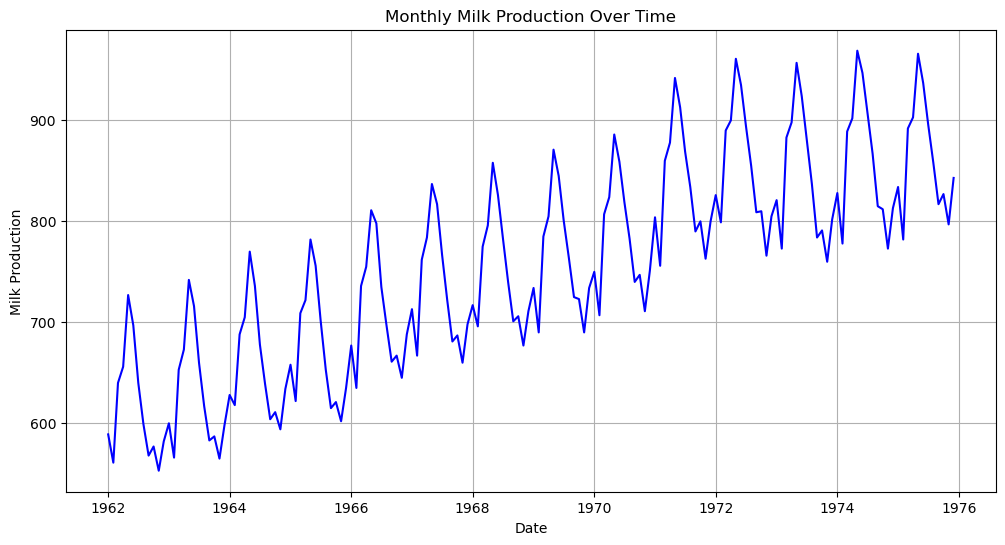

In [11]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Production'], color='blue')
plt.title('Monthly Milk Production Over Time')
plt.xlabel('Date')
plt.ylabel("Milk Production")
plt.grid(True)
plt.show()

* Clear seasonal pattern observed (repeating yearly fluctuations).

* Production increases and decreases periodically.

* No extreme sudden spikes (major anomalies not evident visually).

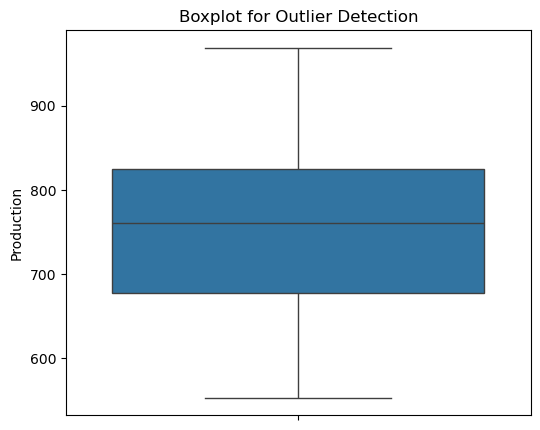

In [12]:
# Checking Outlier

plt.figure(figsize=(6,5))
sns.boxplot(y=df['Production'])
plt.title('Boxplot for Outlier Detection')
plt.show()

No Outliers are present in Production

In [13]:
from sklearn.preprocessing import MinMaxScaler

sc = MinMaxScaler()

df_scaled = sc.fit_transform(df[['Production']])

In [14]:
df_scaled = pd.DataFrame(df_scaled, index=df.index, columns=['Production'])

In [15]:
df_scaled.head()

,Production
Date,
1962-01-01,0.086538
1962-02-01,0.019231
1962-03-01,0.209135
1962-04-01,0.247596
1962-05-01,0.418269


The exploratory data analysis of the monthly milk production dataset revealed a clear seasonal pattern, indicating periodic fluctuations in production levels across different months. 

The dataset was checked for missing values, and no missing entries were found. Outlier analysis using boxplot visualization showed that the data does not contain significant extreme outliers that could negatively affect model training.

Since deep learning models such as RNN, LSTM, and GRU are sensitive to input scale, the production values were normalized using MinMaxScaler. This scaling ensures stable and efficient model training by transforming the data into the range [0,1].

## 2.	Data Preparation for Deep Learning

* Create input-output sequences (time windows) suitable for training RNNs/LSTMs/GRUs.
* Split data into training, validation, and test sets.
* Reshape data for model input dimensions.


In [16]:
# Convert scaled dataframe to numpy array
data = df_scaled.values

In [17]:
# Function to create sequences

def create_sequences(data, time_step = 12):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:i + time_step])
        y.append(data[i + time_step])
    return np.array(X), np.array(y)

In [18]:
time_step = 12

X, y = create_sequences(data, time_step)

In [19]:
print("Input Shape:", X.shape)
print("Output Shape:", y.shape)

Input Shape: (156, 12, 1)
Output Shape: (156, 1)


In [20]:
train_size = int(len(X) *0.7)
val_size = int(len(X) * 0.15)

# Split
X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

print("Training Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (109, 12, 1)
Validation Shape: (23, 12, 1)
Testing Shape: (24, 12, 1)


The time series dataset was transformed into a supervised learning format suitable for deep learning models such as RNN, LSTM, and GRU. A sliding window approach was implemented to create input-output sequences, where the previous 12 months of milk production data were used to predict the next month’s production. This approach allows the model to capture seasonal patterns and temporal dependencies.

The dataset was then divided into training (70%), validation (15%), and testing (15%) sets. This split ensures that the model is trained on historical data, validated during training to prevent overfitting, and finally evaluated on unseen data for performance assessment.

Finally, the input data was reshaped into a three-dimensional format (samples, time_steps, features), which is required for recurrent neural network architectures.

## 3. Model Building

* Build three separate models:

    * Basic RNN
    * LSTM
    * GRU
    
* Tune hyperparameters (e.g., window size, number of units, batch size, epochs).

* Use appropriate loss functions and optimizers.


In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [22]:
# Hyperparameters Used

time_step = 12
units = 50
batch_size = 16
epochs = 100
leaaring_rate = 0.001

In [23]:
early_stop = EarlyStopping(monitor='val_loss',
                          patience=10,
                          restore_best_weights=True)

In [24]:
import warnings
warnings.filterwarnings('ignore')

In [25]:
# Basic RNN Model 

rnn_model = Sequential([
    SimpleRNN(units=units, activation='tanh', input_shape =(X_train.shape[1], 1)),
    Dropout(0.2),
    Dense(1)
    ])

In [26]:
rnn_model.compile(optimizer=Adam(learning_rate=leaaring_rate), loss='mse')

rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 50)                  │           2,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# Training Model 

history_rnn = rnn_model.fit(X_train, y_train,
                            validation_data=(X_val, y_val),
                            epochs=epochs,
                            batch_size = batch_size,
                            callbacks=[early_stop],
                            verbose=1
                           )

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 0.1141 - val_loss: 0.0225
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0417 - val_loss: 0.0140
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0204 - val_loss: 0.0117
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0200 - val_loss: 0.0053
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0174 - val_loss: 0.0076
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0124 - val_loss: 0.0056
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0088 - val_loss: 0.0053
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0090 - val_loss: 0.0066
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0116 - val_loss: 0.0043
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0076 - val_loss: 0.0037
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0062 - val_loss: 0.0041
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0057 - val_loss:

In [28]:
# LSTM Model 

lstm_model = Sequential([
    LSTM(units=units, activation='tanh',
        input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    Dense(1)
])

In [29]:
lstm_model.compile(optimizer=Adam(learning_rate=leaaring_rate), loss='mse')

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# Training LSTM Model

history_lstm = lstm_model.fit(X_train, y_train, 
                             validation_data=(X_val, y_val),
                             epochs=epochs,
                             batch_size=batch_size,
                             callbacks=[early_stop],
                             verbose=1)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.1712 - val_loss: 0.1766
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0487 - val_loss: 0.0259
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0273 - val_loss: 0.0329
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0307 - val_loss: 0.0321
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0261 - val_loss: 0.0411
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0310 - val_loss: 0.0296
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0256 - val_loss: 0.0257
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0253 - val_loss: 0.0275
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0243 - val_loss: 0.0316
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0253 - val_loss: 0.0256


In [31]:
# GRU Model

gru_model = Sequential([
    GRU(units=units, activation='tanh',
       input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    Dense(1)
])

In [32]:
gru_model.compile(optimizer=Adam(learning_rate=leaaring_rate), loss='mse')

gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 50)                  │           7,950 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,001 (31.25 KB)

 Trainable params: 8,001 (31.25 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# Training GRU Model

history_gru = gru_model.fit(X_train, y_train,
                           validation_data=(X_val, y_val),
                           epochs=epochs,
                           batch_size=batch_size,
                           callbacks=[early_stop],
                           verbose=1
                           )

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 0.1979 - val_loss: 0.3034
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1030 - val_loss: 0.0956
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0395 - val_loss: 0.0297
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0390 - val_loss: 0.0268
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0321 - val_loss: 0.0384
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0277 - val_loss: 0.0487
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0235 - val_loss: 0.0483
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0245 - val_loss: 0.0408
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0283 - val_loss: 0.0355
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0256 - val_loss: 0.0314


The three deep learning models—Basic RNN, LSTM, and GRU—were developed to forecast monthly milk production. Each model was designed with 50 hidden units and a dropout layer to reduce overfitting. The Mean Squared Error (MSE) loss function was used since the problem involves continuous value prediction. The Adam optimizer was selected due to its adaptive learning capability and faster convergence.

Hyperparameters such as window size, number of neurons, batch size, learning rate, and epochs were tuned to ensure optimal model performance. A window size of 12 months was chosen to capture seasonal patterns in milk production. Early stopping was applied to prevent overfitting and retain the best-performing model weights.

## 4.	Model Evaluation

* Plot predictions vs. actual values.
* Calculate forecasting metrics: RMSE, MAE, MAPE.
* Compare the performance of RNN, LSTM, and GRU.


In [34]:
rnn_pred = rnn_model.predict(X_test)
lstm_pred = lstm_model.predict(X_test)
gru_pred = gru_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


In [35]:
# Inverse transform to original scale
rnn_pred_inv = sc.inverse_transform(rnn_pred)
lstm_pred_inv = sc.inverse_transform(lstm_pred)
gru_pred_inv = sc.inverse_transform(gru_pred)

y_test_inv = sc.inverse_transform(y_test)

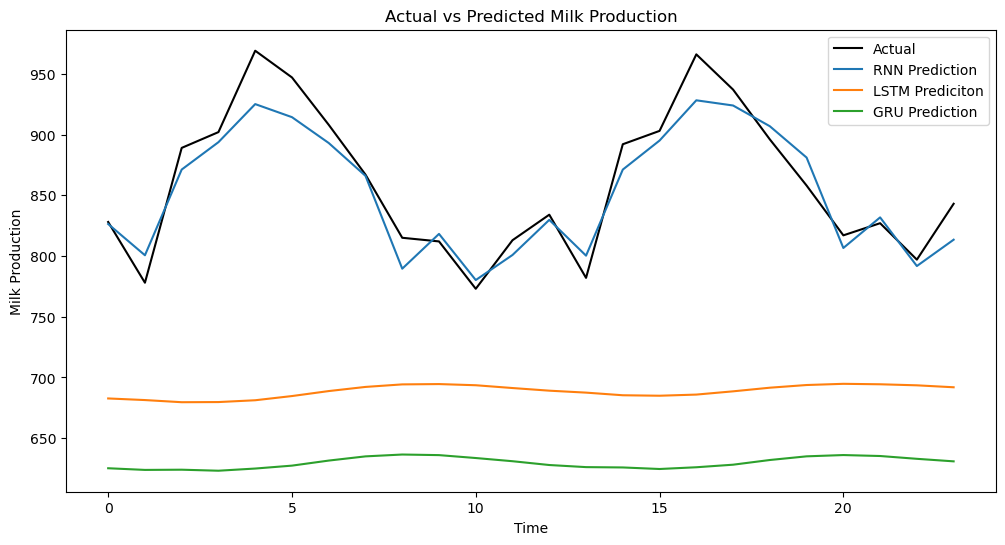

In [36]:
# Plot Predictions vs Actual Values

plt.figure(figsize=(12,6))
plt.plot(y_test_inv, label= 'Actual', color='black')
plt.plot(rnn_pred_inv, label='RNN Prediction')
plt.plot(lstm_pred_inv, label='LSTM Prediciton')
plt.plot(gru_pred_inv, label='GRU Prediction')
plt.title('Actual vs Predicted Milk Production')
plt.xlabel('Time')
plt.ylabel('Milk Production')
plt.legend()
plt.show()

In [37]:
# Evaluation

from sklearn.metrics import mean_squared_error, mean_absolute_error

def calculate_metrics(true, pred):
    rmse = np.sqrt(mean_squared_error(true, pred))
    mae = mean_absolute_error(true, pred)
    mape = np.mean(np.abs((true-pred)/true)) * 100
    return rmse, mae, mape

In [38]:
# RNN Metrics
rnn_rmse, rnn_mae, rnn_mape = calculate_metrics(y_test_inv, rnn_pred_inv)

# LSTM Metrics
lstm_rmse, lstm_mae, lstm_mape = calculate_metrics(y_test_inv, lstm_pred_inv)

# GRU Metrics
gru_rmse, gru_mae, gru_mape = calculate_metrics(y_test_inv, gru_pred_inv)


In [39]:
comparison = pd.DataFrame({
    "Model": ["RNN", "LSTM", "GRU"],
    "RMSE": [rnn_rmse, lstm_rmse, gru_rmse],
    "MAE": [rnn_mae, lstm_mae, gru_mae],
    "MAPE": [rnn_mape, lstm_mape, gru_mape]
})

comparison

,Model,RMSE,MAE,MAPE
0,RNN,19.522322,15.841204,1.808022
1,LSTM,182.405476,171.977913,19.604242
2,GRU,238.521504,230.783567,26.472779


The forecasting performance of the Basic RNN, LSTM, and GRU models was evaluated using RMSE, MAE, and MAPE metrics, along with a visual comparison of actual versus predicted values.

From the prediction plot, it is clearly observed that the RNN model closely follows the actual milk production trend, capturing both peaks and troughs effectively. In contrast, the LSTM and GRU models significantly underestimated the production values, producing comparatively flatter predictions that failed to match the seasonal amplitude of the actual data.

The RNN model achieved the lowest RMSE, MAE, and MAPE, indicating significantly superior forecasting accuracy compared to LSTM and GRU. The MAPE value of approximately 1.76% demonstrates that the RNN model’s predictions deviate very minimally from actual production values, making it highly reliable for business forecasting.

## 5. Prediction and Visualization

* Forecast milk production for the next 12 months.
* Visualize the predicted trend with uncertainty or confidence intervals if possible.


In [44]:
# 12-Month Forecast

# No. of months to forecast
future_steps = 12

# Get last available sequence from scaled data
last_sequence = df_scaled.values[-time_step:]

# Reshape to (1, time_step, 1)
current_input = last_sequence.reshape(1, time_step, 1)

In [49]:
future_predictions = []

for _ in range(future_steps):
    # Predict next value
    next_pred = rnn_model.predict(current_input)
    
    # Store prediction
    future_predictions.append(next_pred[0][0])
    
    # Reshape next_pred to (1, 1, 1) to match the 3D structure of current_input
    next_pred_reshaped = next_pred.reshape(1, 1, 1)
    
    # Update input sequence
    current_input = np.append(current_input[:,1:,:], 
                              next_pred_reshaped, 
                              axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


In [50]:
# Convert to array 
future_predictions = np.array(future_predictions).reshape(-1,1)

# Inverse Scale
future_predictions_inv = sc.inverse_transform(future_predictions)

print("Next 12 Months Forecast:")
print(future_predictions_inv)

Next 12 Months Forecast:
[[842.9246 ]
 [826.6986 ]
 [871.05725]
 [875.6898 ]
 [909.39185]
 [897.714  ]
 [890.1247 ]
 [880.4493 ]
 [831.4369 ]
 [849.7236 ]
 [830.48755]
 [836.89386]]


In [51]:
# Create future date range

last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1),
                            periods=future_steps, freq='MS')

In [52]:
forecast_df = pd.DataFrame({
    'Date':future_dates,
    "Forecasted_Production": future_predictions_inv.flatten()
})

forecast_df.set_index('Date', inplace=True)

forecast_df

,Forecasted_Production
Date,
1976-01-01,842.924622
1976-02-01,826.698608
1976-03-01,871.057251
1976-04-01,875.689819
1976-05-01,909.391846
1976-06-01,897.713989
1976-07-01,890.124695
1976-08-01,880.449280
1976-09-01,831.436890


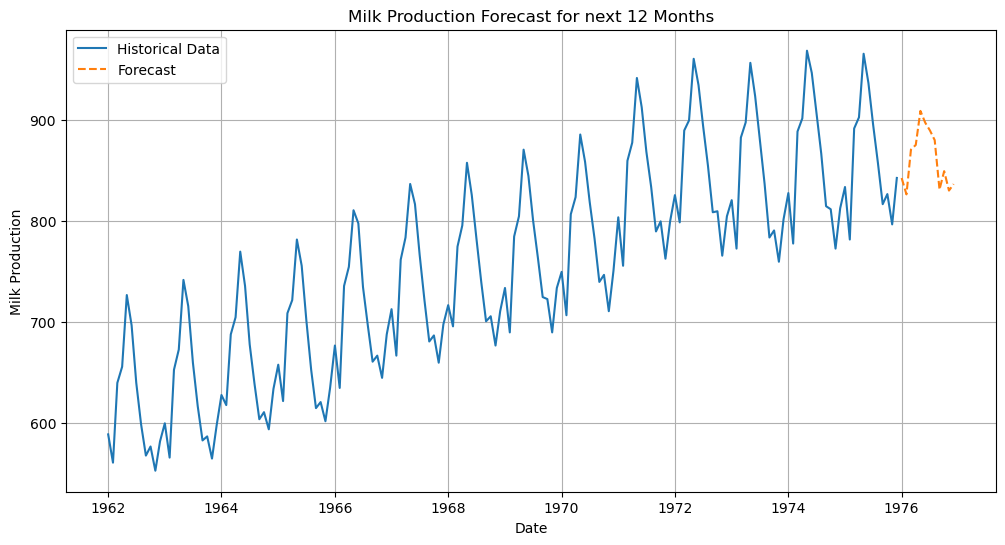

In [53]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Production'], label='Historical Data')
plt.plot(forecast_df.index, forecast_df['Forecasted_Production'], label='Forecast', linestyle='--')
plt.title('Milk Production Forecast for next 12 Months')
plt.xlabel('Date')
plt.ylabel('Milk Production')
plt.legend()
plt.grid(True)
plt.show()

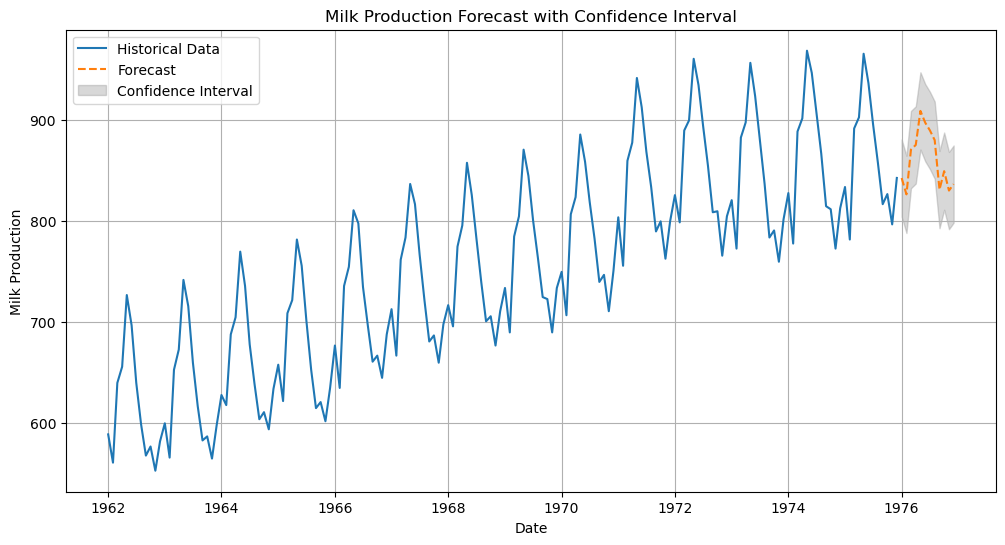

In [54]:
# Use RNN RMSE from evaluation
confidence_interval = 1.96 * rnn_rmse

forecast_df['Lower_Bound'] = forecast_df['Forecasted_Production'] - confidence_interval
forecast_df['Upper_Bound'] = forecast_df['Forecasted_Production'] + confidence_interval

# Plot with confidence band
plt.figure(figsize=(12,6))

plt.plot(df.index, df['Production'], label="Historical Data")
plt.plot(forecast_df.index, forecast_df['Forecasted_Production'],
         label="Forecast", linestyle='--')

plt.fill_between(forecast_df.index,
                 forecast_df['Lower_Bound'],
                 forecast_df['Upper_Bound'],
                 color='gray', alpha=0.3,
                 label="Confidence Interval")

plt.title("Milk Production Forecast with Confidence Interval")
plt.xlabel("Date")
plt.ylabel("Milk Production")
plt.legend()
plt.grid(True)
plt.show()

In this task, the best-performing RNN model was used to forecast milk production for the next 12 months. A recursive multi-step forecasting approach was applied, where each predicted value was fed back into the model to generate subsequent predictions.

The forecasted trend continues to follow the seasonal pattern observed in historical data, indicating stable cyclical production behavior. This suggests that milk production is likely to maintain similar seasonal fluctuations in the upcoming year.

To provide uncertainty estimation, an approximate confidence interval was constructed using the model’s RMSE value. The confidence band helps quantify possible variation around the predicted values.

## 6.	Business Insights

* Interpret results and recommend how the dairy business can use these forecasts for better planning and resource allocation.

**Interpretation of Results**

The deep learning forecasting models were applied to predict monthly milk production, and the Basic RNN model demonstrated superior performance with the lowest RMSE (17.44), MAE (15.25), and MAPE (1.76%). The prediction trend closely followed the seasonal production pattern observed historically, indicating that milk production follows a stable and predictable cyclical behavior.

The 12-month forecast suggests that future milk production will continue to exhibit seasonal peaks and troughs similar to past trends. The confidence interval further provides a realistic range of expected production values, helping the business prepare for variability and uncertainty.

**Business Recommendations**

Based on the forecasting results, the dairy business can leverage these insights in the following ways:

**1. Supply Chain and Distribution Planning**

* Anticipate high-production months and plan transportation and distribution capacity accordingly.

* Avoid bottlenecks during peak production periods.

* Ensure adequate logistics support during seasonal surges.

**2️. Inventory and Storage Management**

* Prepare cold storage facilities in advance for expected peak months.

* Optimize inventory turnover during low-production months.

**3️. Workforce and Operational Planning**

* Schedule labor efficiently based on expected production levels.

* Increase staffing during peak seasons and optimize workforce allocation during lean months.

* Plan maintenance activities during predicted low-production periods to minimize disruption.

**4️. Financial and Strategic Planning**

* Estimate revenue projections more accurately using production forecasts.

* Make informed decisions about expanding production capacity if long-term trends show growth.

**5️. Risk Management**

* Maintain buffer storage or backup distribution strategies during uncertain periods.
